In [1]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
DATA_DIR = "Dataset"

categories = ["real", "fake"]
img_size = 128

In [3]:
#resizing all the images and saved into a big list 
data = []

for category in categories:
    path = os.path.join(DATA_DIR, category)
    label = categories.index(category)

    for img in os.listdir(path):
        try:
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)
            image = cv2.resize(image, (img_size, img_size))

            data.append([image, label])

        except Exception as e:
            pass

print("Total images loaded:", len(data))

Total images loaded: 12890


In [4]:
# we are giving labels here 
X = np.array([i[0] for i in data]) / 255.0
y = np.array([i[1] for i in data])

In [5]:
#the data is spliting into two types 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
#This builds the actual CNN (Convolutional Neural Network) — the model architecture itself.
model = models.Sequential([
    
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

c:\Users\lolla\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
#you're telling the model — "use Adam to learn, measure mistakes with binary crossentropy since this is a 2-class problem, and show me accuracy as you go.
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
#This is the actual training step — where the model starts learning from your data.
history = model.fit(
    X_train, y_train,
    epochs=5,
    validation_data=(X_test, y_test),
    batch_size=32
)

Epoch 1/5
323/323 ━━━━━━━━━━━━━━━━━━━━ 42s 121ms/step - accuracy: 0.6415 - loss: 0.6380 - val_accuracy: 0.6874 - val_loss: 0.5760
Epoch 2/5
323/323 ━━━━━━━━━━━━━━━━━━━━ 37s 114ms/step - accuracy: 0.7134 - loss: 0.5456 - val_accuracy: 0.7254 - val_loss: 0.5198
Epoch 3/5
323/323 ━━━━━━━━━━━━━━━━━━━━ 36s 113ms/step - accuracy: 0.7525 - loss: 0.4777 - val_accuracy: 0.7766 - val_loss: 0.4361
Epoch 4/5
323/323 ━━━━━━━━━━━━━━━━━━━━ 37s 113ms/step - accuracy: 0.7904 - loss: 0.4230 - val_accuracy: 0.7839 - val_loss: 0.4292
Epoch 5/5
323/323 ━━━━━━━━━━━━━━━━━━━━ 37s 115ms/step - accuracy: 0.8186 - loss: 0.3744 - val_accuracy: 0.7929 - val_loss: 0.4167


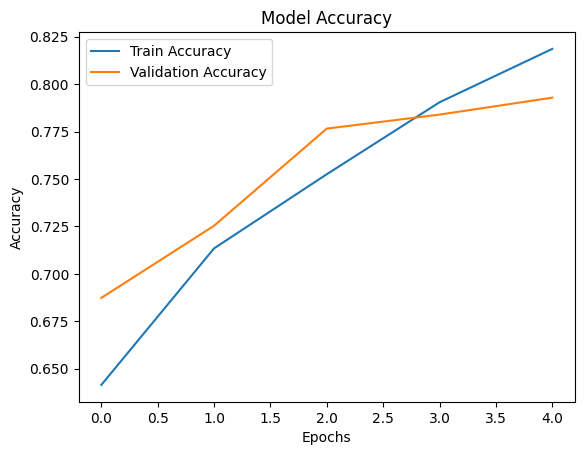

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [10]:
model.save("fake_image_model.h5")
print("Model saved successfully!")

Model saved successfully!
